# Statistics

A statistics report asks the same questions in the same order: do these groups really differ, how large is the difference and how sure can we be of it, which measurements move together, and does the line fitted through them hold up. This page walks one dataset through those questions and names the figure that answers each, so the chart to reach for arrives with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

The dataset is the **Palmer penguins** (Gorman et al. 2014, [CC0](https://creativecommons.org/publicdomain/zero/1.0/)): the bill length, bill depth, flipper length, body mass, species and sex of 344 penguins measured on the Palmer Archipelago, Antarctica. Two birds were never measured and are dropped, leaving 342. The hypothesis tests are `scipy.stats` calls written out in the open, and the intervals are bootstrap resamples; datachart draws what they produce and the [statistics utilities](../../how-to-guides/utility/stats/) supply the rest.

In [1]:
import numpy as np
from scipy import stats as scipy_stats

from datachart.charts import (
    Heatmap,
    Histogram,
    LineChart,
    RaincloudPlot,
    ScatterChart,
    ScatterMatrix,
)
from datachart.constants import (
    ASPECT_RATIO,
    FIG_SIZE,
    LINE_DRAW_STYLE,
    NORMALIZE,
    SCATTER_MATRIX_DIAGONAL,
    SHOW_GRID,
    VALUE_FORMAT,
)
from datachart.utils import Grid
from datachart.utils.stats import correlation, linear_fit, spearman

The hidden cell below holds the measurements themselves. `PENGUIN_ROWS` is the table as published, one tuple per bird per species; `MEASUREMENTS` names the four numeric columns in order and `SEXES` spells the sex codes out; `penguins` is the list of records the whole page works from, one dict per bird. Every section that follows starts from those four names.

In [2]:
# Palmer penguins (Gorman et al. 2014, CC0), by species; the two birds whose
# measurements are all missing are not in the table, so 342 of the 344 remain:
# (bill length mm, bill depth mm, flipper length mm, body mass g, sex)
PENGUIN_ROWS = {
    "Adelie": [
        (39.1, 18.7, 181, 3750, "m"), (39.5, 17.4, 186, 3800, "f"), (40.3, 18, 195, 3250, "f"),
        (36.7, 19.3, 193, 3450, "f"), (39.3, 20.6, 190, 3650, "m"), (38.9, 17.8, 181, 3625, "f"),
        (39.2, 19.6, 195, 4675, "m"), (34.1, 18.1, 193, 3475, None), (42, 20.2, 190, 4250, None),
        (37.8, 17.1, 186, 3300, None), (37.8, 17.3, 180, 3700, None), (41.1, 17.6, 182, 3200, "f"),
        (38.6, 21.2, 191, 3800, "m"), (34.6, 21.1, 198, 4400, "m"), (36.6, 17.8, 185, 3700, "f"),
        (38.7, 19, 195, 3450, "f"), (42.5, 20.7, 197, 4500, "m"), (34.4, 18.4, 184, 3325, "f"),
        (46, 21.5, 194, 4200, "m"), (37.8, 18.3, 174, 3400, "f"), (37.7, 18.7, 180, 3600, "m"),
        (35.9, 19.2, 189, 3800, "f"), (38.2, 18.1, 185, 3950, "m"), (38.8, 17.2, 180, 3800, "m"),
        (35.3, 18.9, 187, 3800, "f"), (40.6, 18.6, 183, 3550, "m"), (40.5, 17.9, 187, 3200, "f"),
        (37.9, 18.6, 172, 3150, "f"), (40.5, 18.9, 180, 3950, "m"), (39.5, 16.7, 178, 3250, "f"),
        (37.2, 18.1, 178, 3900, "m"), (39.5, 17.8, 188, 3300, "f"), (40.9, 18.9, 184, 3900, "m"),
        (36.4, 17, 195, 3325, "f"), (39.2, 21.1, 196, 4150, "m"), (38.8, 20, 190, 3950, "m"),
        (42.2, 18.5, 180, 3550, "f"), (37.6, 19.3, 181, 3300, "f"), (39.8, 19.1, 184, 4650, "m"),
        (36.5, 18, 182, 3150, "f"), (40.8, 18.4, 195, 3900, "m"), (36, 18.5, 186, 3100, "f"),
        (44.1, 19.7, 196, 4400, "m"), (37, 16.9, 185, 3000, "f"), (39.6, 18.8, 190, 4600, "m"),
        (41.1, 19, 182, 3425, "m"), (37.5, 18.9, 179, 2975, None), (36, 17.9, 190, 3450, "f"),
        (42.3, 21.2, 191, 4150, "m"), (39.6, 17.7, 186, 3500, "f"), (40.1, 18.9, 188, 4300, "m"),
        (35, 17.9, 190, 3450, "f"), (42, 19.5, 200, 4050, "m"), (34.5, 18.1, 187, 2900, "f"),
        (41.4, 18.6, 191, 3700, "m"), (39, 17.5, 186, 3550, "f"), (40.6, 18.8, 193, 3800, "m"),
        (36.5, 16.6, 181, 2850, "f"), (37.6, 19.1, 194, 3750, "m"), (35.7, 16.9, 185, 3150, "f"),
        (41.3, 21.1, 195, 4400, "m"), (37.6, 17, 185, 3600, "f"), (41.1, 18.2, 192, 4050, "m"),
        (36.4, 17.1, 184, 2850, "f"), (41.6, 18, 192, 3950, "m"), (35.5, 16.2, 195, 3350, "f"),
        (41.1, 19.1, 188, 4100, "m"), (35.9, 16.6, 190, 3050, "f"), (41.8, 19.4, 198, 4450, "m"),
        (33.5, 19, 190, 3600, "f"), (39.7, 18.4, 190, 3900, "m"), (39.6, 17.2, 196, 3550, "f"),
        (45.8, 18.9, 197, 4150, "m"), (35.5, 17.5, 190, 3700, "f"), (42.8, 18.5, 195, 4250, "m"),
        (40.9, 16.8, 191, 3700, "f"), (37.2, 19.4, 184, 3900, "m"), (36.2, 16.1, 187, 3550, "f"),
        (42.1, 19.1, 195, 4000, "m"), (34.6, 17.2, 189, 3200, "f"), (42.9, 17.6, 196, 4700, "m"),
        (36.7, 18.8, 187, 3800, "f"), (35.1, 19.4, 193, 4200, "m"), (37.3, 17.8, 191, 3350, "f"),
        (41.3, 20.3, 194, 3550, "m"), (36.3, 19.5, 190, 3800, "m"), (36.9, 18.6, 189, 3500, "f"),
        (38.3, 19.2, 189, 3950, "m"), (38.9, 18.8, 190, 3600, "f"), (35.7, 18, 202, 3550, "f"),
        (41.1, 18.1, 205, 4300, "m"), (34, 17.1, 185, 3400, "f"), (39.6, 18.1, 186, 4450, "m"),
        (36.2, 17.3, 187, 3300, "f"), (40.8, 18.9, 208, 4300, "m"), (38.1, 18.6, 190, 3700, "f"),
        (40.3, 18.5, 196, 4350, "m"), (33.1, 16.1, 178, 2900, "f"), (43.2, 18.5, 192, 4100, "m"),
        (35, 17.9, 192, 3725, "f"), (41, 20, 203, 4725, "m"), (37.7, 16, 183, 3075, "f"),
        (37.8, 20, 190, 4250, "m"), (37.9, 18.6, 193, 2925, "f"), (39.7, 18.9, 184, 3550, "m"),
        (38.6, 17.2, 199, 3750, "f"), (38.2, 20, 190, 3900, "m"), (38.1, 17, 181, 3175, "f"),
        (43.2, 19, 197, 4775, "m"), (38.1, 16.5, 198, 3825, "f"), (45.6, 20.3, 191, 4600, "m"),
        (39.7, 17.7, 193, 3200, "f"), (42.2, 19.5, 197, 4275, "m"), (39.6, 20.7, 191, 3900, "f"),
        (42.7, 18.3, 196, 4075, "m"), (38.6, 17, 188, 2900, "f"), (37.3, 20.5, 199, 3775, "m"),
        (35.7, 17, 189, 3350, "f"), (41.1, 18.6, 189, 3325, "m"), (36.2, 17.2, 187, 3150, "f"),
        (37.7, 19.8, 198, 3500, "m"), (40.2, 17, 176, 3450, "f"), (41.4, 18.5, 202, 3875, "m"),
        (35.2, 15.9, 186, 3050, "f"), (40.6, 19, 199, 4000, "m"), (38.8, 17.6, 191, 3275, "f"),
        (41.5, 18.3, 195, 4300, "m"), (39, 17.1, 191, 3050, "f"), (44.1, 18, 210, 4000, "m"),
        (38.5, 17.9, 190, 3325, "f"), (43.1, 19.2, 197, 3500, "m"), (36.8, 18.5, 193, 3500, "f"),
        (37.5, 18.5, 199, 4475, "m"), (38.1, 17.6, 187, 3425, "f"), (41.1, 17.5, 190, 3900, "m"),
        (35.6, 17.5, 191, 3175, "f"), (40.2, 20.1, 200, 3975, "m"), (37, 16.5, 185, 3400, "f"),
        (39.7, 17.9, 193, 4250, "m"), (40.2, 17.1, 193, 3400, "f"), (40.6, 17.2, 187, 3475, "m"),
        (32.1, 15.5, 188, 3050, "f"), (40.7, 17, 190, 3725, "m"), (37.3, 16.8, 192, 3000, "f"),
        (39, 18.7, 185, 3650, "m"), (39.2, 18.6, 190, 4250, "m"), (36.6, 18.4, 184, 3475, "f"),
        (36, 17.8, 195, 3450, "f"), (37.8, 18.1, 193, 3750, "m"), (36, 17.1, 187, 3700, "f"),
        (41.5, 18.5, 201, 4000, "m"),
    ],
    "Chinstrap": [
        (46.5, 17.9, 192, 3500, "f"), (50, 19.5, 196, 3900, "m"), (51.3, 19.2, 193, 3650, "m"),
        (45.4, 18.7, 188, 3525, "f"), (52.7, 19.8, 197, 3725, "m"), (45.2, 17.8, 198, 3950, "f"),
        (46.1, 18.2, 178, 3250, "f"), (51.3, 18.2, 197, 3750, "m"), (46, 18.9, 195, 4150, "f"),
        (51.3, 19.9, 198, 3700, "m"), (46.6, 17.8, 193, 3800, "f"), (51.7, 20.3, 194, 3775, "m"),
        (47, 17.3, 185, 3700, "f"), (52, 18.1, 201, 4050, "m"), (45.9, 17.1, 190, 3575, "f"),
        (50.5, 19.6, 201, 4050, "m"), (50.3, 20, 197, 3300, "m"), (58, 17.8, 181, 3700, "f"),
        (46.4, 18.6, 190, 3450, "f"), (49.2, 18.2, 195, 4400, "m"), (42.4, 17.3, 181, 3600, "f"),
        (48.5, 17.5, 191, 3400, "m"), (43.2, 16.6, 187, 2900, "f"), (50.6, 19.4, 193, 3800, "m"),
        (46.7, 17.9, 195, 3300, "f"), (52, 19, 197, 4150, "m"), (50.5, 18.4, 200, 3400, "f"),
        (49.5, 19, 200, 3800, "m"), (46.4, 17.8, 191, 3700, "f"), (52.8, 20, 205, 4550, "m"),
        (40.9, 16.6, 187, 3200, "f"), (54.2, 20.8, 201, 4300, "m"), (42.5, 16.7, 187, 3350, "f"),
        (51, 18.8, 203, 4100, "m"), (49.7, 18.6, 195, 3600, "m"), (47.5, 16.8, 199, 3900, "f"),
        (47.6, 18.3, 195, 3850, "f"), (52, 20.7, 210, 4800, "m"), (46.9, 16.6, 192, 2700, "f"),
        (53.5, 19.9, 205, 4500, "m"), (49, 19.5, 210, 3950, "m"), (46.2, 17.5, 187, 3650, "f"),
        (50.9, 19.1, 196, 3550, "m"), (45.5, 17, 196, 3500, "f"), (50.9, 17.9, 196, 3675, "f"),
        (50.8, 18.5, 201, 4450, "m"), (50.1, 17.9, 190, 3400, "f"), (49, 19.6, 212, 4300, "m"),
        (51.5, 18.7, 187, 3250, "m"), (49.8, 17.3, 198, 3675, "f"), (48.1, 16.4, 199, 3325, "f"),
        (51.4, 19, 201, 3950, "m"), (45.7, 17.3, 193, 3600, "f"), (50.7, 19.7, 203, 4050, "m"),
        (42.5, 17.3, 187, 3350, "f"), (52.2, 18.8, 197, 3450, "m"), (45.2, 16.6, 191, 3250, "f"),
        (49.3, 19.9, 203, 4050, "m"), (50.2, 18.8, 202, 3800, "m"), (45.6, 19.4, 194, 3525, "f"),
        (51.9, 19.5, 206, 3950, "m"), (46.8, 16.5, 189, 3650, "f"), (45.7, 17, 195, 3650, "f"),
        (55.8, 19.8, 207, 4000, "m"), (43.5, 18.1, 202, 3400, "f"), (49.6, 18.2, 193, 3775, "m"),
        (50.8, 19, 210, 4100, "m"), (50.2, 18.7, 198, 3775, "f"),
    ],
    "Gentoo": [
        (46.1, 13.2, 211, 4500, "f"), (50, 16.3, 230, 5700, "m"), (48.7, 14.1, 210, 4450, "f"),
        (50, 15.2, 218, 5700, "m"), (47.6, 14.5, 215, 5400, "m"), (46.5, 13.5, 210, 4550, "f"),
        (45.4, 14.6, 211, 4800, "f"), (46.7, 15.3, 219, 5200, "m"), (43.3, 13.4, 209, 4400, "f"),
        (46.8, 15.4, 215, 5150, "m"), (40.9, 13.7, 214, 4650, "f"), (49, 16.1, 216, 5550, "m"),
        (45.5, 13.7, 214, 4650, "f"), (48.4, 14.6, 213, 5850, "m"), (45.8, 14.6, 210, 4200, "f"),
        (49.3, 15.7, 217, 5850, "m"), (42, 13.5, 210, 4150, "f"), (49.2, 15.2, 221, 6300, "m"),
        (46.2, 14.5, 209, 4800, "f"), (48.7, 15.1, 222, 5350, "m"), (50.2, 14.3, 218, 5700, "m"),
        (45.1, 14.5, 215, 5000, "f"), (46.5, 14.5, 213, 4400, "f"), (46.3, 15.8, 215, 5050, "m"),
        (42.9, 13.1, 215, 5000, "f"), (46.1, 15.1, 215, 5100, "m"), (44.5, 14.3, 216, 4100, None),
        (47.8, 15, 215, 5650, "m"), (48.2, 14.3, 210, 4600, "f"), (50, 15.3, 220, 5550, "m"),
        (47.3, 15.3, 222, 5250, "m"), (42.8, 14.2, 209, 4700, "f"), (45.1, 14.5, 207, 5050, "f"),
        (59.6, 17, 230, 6050, "m"), (49.1, 14.8, 220, 5150, "f"), (48.4, 16.3, 220, 5400, "m"),
        (42.6, 13.7, 213, 4950, "f"), (44.4, 17.3, 219, 5250, "m"), (44, 13.6, 208, 4350, "f"),
        (48.7, 15.7, 208, 5350, "m"), (42.7, 13.7, 208, 3950, "f"), (49.6, 16, 225, 5700, "m"),
        (45.3, 13.7, 210, 4300, "f"), (49.6, 15, 216, 4750, "m"), (50.5, 15.9, 222, 5550, "m"),
        (43.6, 13.9, 217, 4900, "f"), (45.5, 13.9, 210, 4200, "f"), (50.5, 15.9, 225, 5400, "m"),
        (44.9, 13.3, 213, 5100, "f"), (45.2, 15.8, 215, 5300, "m"), (46.6, 14.2, 210, 4850, "f"),
        (48.5, 14.1, 220, 5300, "m"), (45.1, 14.4, 210, 4400, "f"), (50.1, 15, 225, 5000, "m"),
        (46.5, 14.4, 217, 4900, "f"), (45, 15.4, 220, 5050, "m"), (43.8, 13.9, 208, 4300, "f"),
        (45.5, 15, 220, 5000, "m"), (43.2, 14.5, 208, 4450, "f"), (50.4, 15.3, 224, 5550, "m"),
        (45.3, 13.8, 208, 4200, "f"), (46.2, 14.9, 221, 5300, "m"), (45.7, 13.9, 214, 4400, "f"),
        (54.3, 15.7, 231, 5650, "m"), (45.8, 14.2, 219, 4700, "f"), (49.8, 16.8, 230, 5700, "m"),
        (46.2, 14.4, 214, 4650, None), (49.5, 16.2, 229, 5800, "m"), (43.5, 14.2, 220, 4700, "f"),
        (50.7, 15, 223, 5550, "m"), (47.7, 15, 216, 4750, "f"), (46.4, 15.6, 221, 5000, "m"),
        (48.2, 15.6, 221, 5100, "m"), (46.5, 14.8, 217, 5200, "f"), (46.4, 15, 216, 4700, "f"),
        (48.6, 16, 230, 5800, "m"), (47.5, 14.2, 209, 4600, "f"), (51.1, 16.3, 220, 6000, "m"),
        (45.2, 13.8, 215, 4750, "f"), (45.2, 16.4, 223, 5950, "m"), (49.1, 14.5, 212, 4625, "f"),
        (52.5, 15.6, 221, 5450, "m"), (47.4, 14.6, 212, 4725, "f"), (50, 15.9, 224, 5350, "m"),
        (44.9, 13.8, 212, 4750, "f"), (50.8, 17.3, 228, 5600, "m"), (43.4, 14.4, 218, 4600, "f"),
        (51.3, 14.2, 218, 5300, "m"), (47.5, 14, 212, 4875, "f"), (52.1, 17, 230, 5550, "m"),
        (47.5, 15, 218, 4950, "f"), (52.2, 17.1, 228, 5400, "m"), (45.5, 14.5, 212, 4750, "f"),
        (49.5, 16.1, 224, 5650, "m"), (44.5, 14.7, 214, 4850, "f"), (50.8, 15.7, 226, 5200, "m"),
        (49.4, 15.8, 216, 4925, "m"), (46.9, 14.6, 222, 4875, "f"), (48.4, 14.4, 203, 4625, "f"),
        (51.1, 16.5, 225, 5250, "m"), (48.5, 15, 219, 4850, "f"), (55.9, 17, 228, 5600, "m"),
        (47.2, 15.5, 215, 4975, "f"), (49.1, 15, 228, 5500, "m"), (47.3, 13.8, 216, 4725, None),
        (46.8, 16.1, 215, 5500, "m"), (41.7, 14.7, 210, 4700, "f"), (53.4, 15.8, 219, 5500, "m"),
        (43.3, 14, 208, 4575, "f"), (48.1, 15.1, 209, 5500, "m"), (50.5, 15.2, 216, 5000, "f"),
        (49.8, 15.9, 229, 5950, "m"), (43.5, 15.2, 213, 4650, "f"), (51.5, 16.3, 230, 5500, "m"),
        (46.2, 14.1, 217, 4375, "f"), (55.1, 16, 230, 5850, "m"), (44.5, 15.7, 217, 4875, None),
        (48.8, 16.2, 222, 6000, "m"), (47.2, 13.7, 214, 4925, "f"), (46.8, 14.3, 215, 4850, "f"),
        (50.4, 15.7, 222, 5750, "m"), (45.2, 14.8, 212, 5200, "f"), (49.9, 16.1, 213, 5400, "m"),
    ],
}
MEASUREMENTS = ["bill length", "bill depth", "flipper length", "body mass"]
SEXES = {"f": "female", "m": "male", None: None}

penguins = [
    {**dict(zip(MEASUREMENTS, row[:4])), "species": species, "sex": SEXES[row[4]]}
    for species, rows in PENGUIN_ROWS.items()
    for row in rows
]

## Comparing the groups

### Do the three species differ in body mass?

The first figure of a comparison shows the distributions themselves, not their summaries: a test says whether a difference exists, and only the shapes say whether the question was sensible to ask. A [raincloud plot](../../how-to-guides/charts/raincloudplot/) draws all three readings at once — the density of each species, its box, and every bird as a point — so a bimodal group or a stray outlier cannot hide behind a median.

The test beside it is the Kruskal-Wallis H, a rank-based one-way test that asks whether any group sits higher than the others. It is used here in place of a one-way ANOVA because nothing yet says these distributions are normal — the last section of this page asks that question directly. A significant omnibus result says only *some* pair differs, so each pair gets its own Mann-Whitney U test, and the three p-values are corrected for having been asked together with the Holm step-down rule.

In [3]:
SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
PAIRS = [("Adelie", "Chinstrap"), ("Chinstrap", "Gentoo"), ("Adelie", "Gentoo")]


def values(name, species=None):
    """One measurement of every bird, or of one species."""
    return [
        penguin[name]
        for penguin in penguins
        if species is None or penguin["species"] == species
    ]


mass = {species: np.array(values("body mass", species)) for species in SPECIES}

omnibus = scipy_stats.kruskal(*mass.values())
pairwise = [scipy_stats.mannwhitneyu(mass[a], mass[b]).pvalue for a, b in PAIRS]


def holm(pvalues):
    """The Holm step-down adjusted p-values of a family of tests, in input order."""
    order = np.argsort(pvalues)
    multipliers = np.arange(len(pvalues), 0, -1)
    running = np.maximum.accumulate(np.asarray(pvalues)[order] * multipliers)
    adjusted = np.empty(len(pvalues))
    adjusted[order] = np.clip(running, 0, 1)
    return adjusted


adjusted = holm(pairwise)
{f"{a} vs {b}": float(f"{p:.3g}") for (a, b), p in zip(PAIRS, adjusted)}

{'Adelie vs Chinstrap': 0.485,
 'Chinstrap vs Gentoo': 3.34e-28,
 'Adelie vs Gentoo': 8.95e-42}

Each pairwise result becomes a `brackets` entry: the two species by name and the adjusted p-value as its text. The chart places each bracket above the clouds it spans, stacks the ones that overlap, and grows the value axis to fit them, so no position is computed here. The omnibus result is a `texts` note pinned to the axes with `coords="axes"` rather than to a data position.


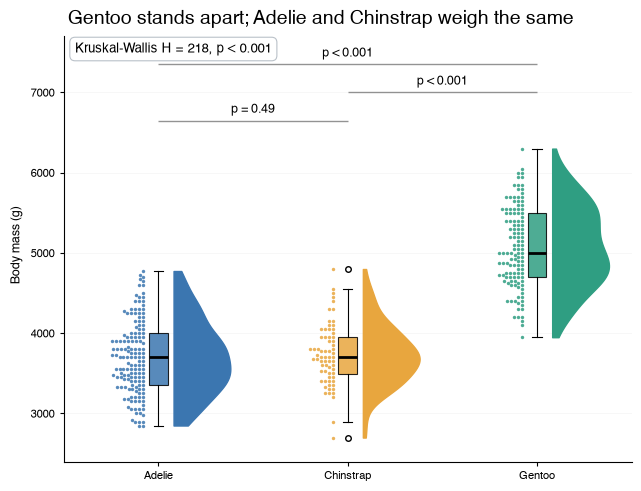

In [4]:
NOTE_STYLE = {"plot_text_size": 9}
REFERENCE_HLINE = {"plot_hline_color": "#666666", "plot_hline_width": 1}


def as_p(pvalue):
    return "p < 0.001" if pvalue < 0.001 else f"p = {pvalue:.2f}"


omnibus_note = f"Kruskal-Wallis H = {omnibus.statistic:.0f}, {as_p(omnibus.pvalue)}"

mass_figure = RaincloudPlot(
    [
        {"label": species, "value": float(value)}
        for species in SPECIES
        for value in mass[species]
    ],
    title="Gentoo stands apart; Adelie and Chinstrap weigh the same",
    ylabel="Body mass (g)",
    ymin=2400,
    # one bracket per pairwise test, named by the species it compares
    brackets=[
        {"from": a, "to": b, "text": as_p(pvalue)}
        for (a, b), pvalue in zip(PAIRS, adjusted)
    ],
    texts={
        "text": omnibus_note,
        "x": 0.02,
        "y": 0.97,
        "coords": "axes",
    },
    figsize=FIG_SIZE.FULL_MEDIUM,
)
mass_figure.show()

The omnibus test is significant, and the brackets say where that came from: Gentoo against either of the others, and nothing between Adelie and Chinstrap, whose clouds sit on top of each other. A table of three p-values would have said the same, but the figure also shows the Chinstrap cloud is the narrowest and the Gentoo box the highest — neither of which a test reports.

### How large is each difference, and how sure can we be of it?

A p-value says a difference is unlikely to be an accident; it never says how large the difference is. The size belongs in its own figure, with an interval attached, and the interval here comes from a bootstrap: both groups are resampled with replacement a few thousand times, the difference of means is recorded each time, and the middle 95% of those recordings is the interval. `bootstrap_ci`, in the [statistics utilities](../../how-to-guides/utility/stats/), does this in one call for a statistic of **one** sample — a mean, a median, an IQR; a difference needs both groups resampled, so the helper below does that and keeps the draws, which the next figure needs anyway.

Each pair is one row, so the differences go on the x-axis of a [scatter chart](../../how-to-guides/charts/scatterchart/) and the pairs on the y-axis. `xerr` takes the interval as *distances* from the point rather than as endpoints, which is the subtraction the chart cannot do for you, and `show_xerr` draws it. The `vlines` zero is the reference every row is read against: a bar that crosses it is a difference the data does not establish.

In [5]:
REFERENCE_VLINE = {"plot_vline_color": "#666666", "plot_vline_width": 1}
RESAMPLES = 4000


def bootstrap_difference(a, b, resamples=RESAMPLES, seed=20260922):
    """The resampled differences between the means of two groups."""
    rng = np.random.default_rng(seed)
    return np.array(
        [
            rng.choice(b, b.size).mean() - rng.choice(a, a.size).mean()
            for _ in range(resamples)
        ]
    )


draws = {pair: bootstrap_difference(mass[pair[0]], mass[pair[1]]) for pair in PAIRS}

effects = [
    {
        "label": f"{b} - {a}",
        "observed": float(mass[b].mean() - mass[a].mean()),
        "low": float(np.quantile(draws[(a, b)], 0.025)),
        "high": float(np.quantile(draws[(a, b)], 0.975)),
    }
    for a, b in PAIRS
]
effects.sort(key=lambda row: row["observed"])
effects

[{'label': 'Chinstrap - Adelie',
  'observed': 32.42598363848856,
  'low': -79.95690494740964,
  'high': 144.5873709583171},
 {'label': 'Gentoo - Chinstrap',
  'observed': 1342.928024868484,
  'low': 1215.6076637972262,
  'high': 1472.2775436394068},
 {'label': 'Gentoo - Adelie',
  'observed': 1375.3540085069726,
  'low': 1262.6115194098963,
  'high': 1488.413153502396}]

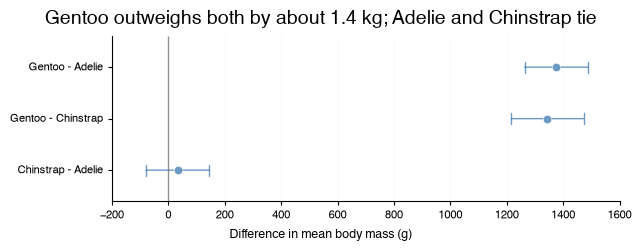

In [6]:
effect_figure = ScatterChart(
    [
        {
            "x": row["observed"],
            "y": position,
            # the bar reaches from the point to each bound, not to the axis
            "xerr": [row["observed"] - row["low"], row["high"] - row["observed"]],
        }
        for position, row in enumerate(effects)
    ],
    title="Gentoo outweighs both by about 1.4 kg; Adelie and Chinstrap tie",
    xlabel="Difference in mean body mass (g)",
    show_xerr=True,
    yticks=list(range(len(effects))),
    yticklabels=[row["label"] for row in effects],
    ymin=-0.6,
    ymax=len(effects) - 0.4,
    # zero: the value a pair that weighs the same would land on
    vlines={"x": 0, "style": REFERENCE_VLINE},
    show_grid=SHOW_GRID.X,
    figsize=FIG_SIZE.FULL_SHORT,
)
effect_figure.show()

The bottom row straddles zero, so the 32 g the sample happens to show is not a difference the data establishes. The other two sit around 1.35 kg with intervals 230 to 260 g wide, under a fifth of the effect. That comparison is what the figure exists for: the bar and the point share one axis, so the size of the uncertainty is read against the size of the finding instead of being quoted beside it.

### What is the interval actually made of?

An interval is two numbers, and two numbers hide the shape they came from. Drawing the resampled differences as a [histogram](../../how-to-guides/charts/histogram/) shows that shape and makes the percentile rule visible: the observed difference is one `vlines` mark, the two bounds are two more, and the bars between them are the 95% the interval claims.

This is worth one figure in a report when the interval is the result — a bootstrap that comes out skewed or multi-peaked is telling you the statistic is unstable, and a symmetric hill like this one is telling you a normal-theory interval would have said the same thing more cheaply.

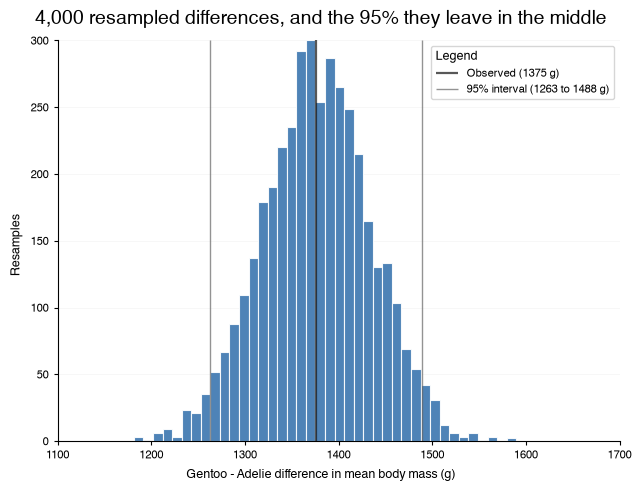

In [7]:
OBSERVED_VLINE = {"plot_vline_color": "#111111", "plot_vline_width": 1.6}

BIGGEST_GAP = ("Adelie", "Gentoo")
gap_draws = draws[BIGGEST_GAP]
low, high = np.quantile(gap_draws, [0.025, 0.975])
observed = mass[BIGGEST_GAP[1]].mean() - mass[BIGGEST_GAP[0]].mean()

Histogram(
    [{"x": float(value)} for value in gap_draws],
    title=f"{RESAMPLES:,} resampled differences, and the 95% they leave in the middle",
    xlabel="Gentoo - Adelie difference in mean body mass (g)",
    ylabel="Resamples",
    num_bins=40,
    vlines=[
        {
            "x": float(observed),
            "label": f"Observed ({observed:.0f} g)",
            "style": OBSERVED_VLINE,
        },
        {
            "x": float(low),
            "label": f"95% interval ({low:.0f} to {high:.0f} g)",
            "style": REFERENCE_VLINE,
        },
        {"x": float(high), "style": REFERENCE_VLINE},
    ],
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The observed difference sits in the middle of the hill, as it must — the bootstrap is centered on the sample. What the figure adds is the width: the resamples spread over a couple of hundred grams, a sixth of the difference itself, so the finding survives any reasonable redraw of the sample.

## Relating the measurements

### Which measurements move together?

With four measurements there are six pairs, and reading six numbers out of a paragraph is what a correlation matrix exists to prevent. The matrix is a square grid of values, so it is a [heatmap](../../how-to-guides/charts/heatmap/) — but a correlation is signed, and a sequential colormap run from the smallest value would put zero on an arbitrary shade. `norm=NORMALIZE.CENTERED` pins zero to the middle of the theme's diverging colormap and runs the same distance to each side, so a cell's hue is its sign and its depth is its strength.

A correlation matrix is also symmetric, which means half of it is decoration. A `None` in `z` leaves a cell blank, so the upper triangle goes; the diagonal of ones goes with the first row and the last column, which hold nothing once it does, and the six numbers that carry information remain.

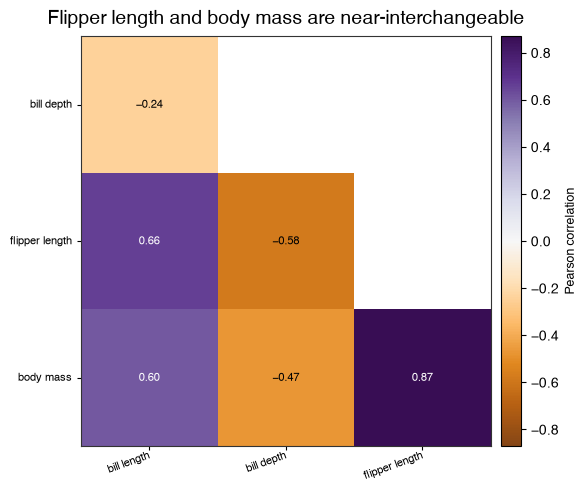

In [8]:
columns = {name: values(name) for name in MEASUREMENTS}

# the lower triangle only: the upper half repeats it and the diagonal is 1,
# so the first row and the last column of the square hold nothing
ROW_NAMES, COLUMN_NAMES = MEASUREMENTS[1:], MEASUREMENTS[:-1]

correlations = [
    [
        round(correlation(columns[row], columns[column]), 2)
        if column_index <= row_index
        else None
        for column_index, column in enumerate(COLUMN_NAMES)
    ]
    for row_index, row in enumerate(ROW_NAMES)
]

correlation_figure = Heatmap(
    {"x": COLUMN_NAMES, "y": ROW_NAMES, "z": correlations},
    title="Flipper length and body mass are near-interchangeable",
    # zero in the middle of the diverging colormap, equal reach each way
    norm=NORMALIZE.CENTERED,
    show_heatmap_values=True,
    show_colorbars=True,
    valfmt=VALUE_FORMAT.DECIMAL_2,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    colorbar={"label": "Pearson correlation"},
    xtickrotate=20,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
correlation_figure.show()

Flipper length and body mass at 0.87 are close to the same measurement taken twice, which matters later: a model given both learns little from the second. The surprise is bill depth, which runs *against* all three others — deeper bills on lighter, shorter-flippered birds. That is the figure's real finding, and the next two exist to explain it.

### What is a single correlation hiding?

A correlation over the whole table is a correlation over a mixture of three species, and a mixture can invert the relationship inside every group it contains. The figure that shows this is a [scatter matrix](../../how-to-guides/charts/scattermatrix/): every pair of measurements as its own scatter, colored by species with `hue`, so the pooled cloud and the three clouds inside it are visible at once. `lower_only` drops the mirrored half, matching the heatmap above, and a `KDE` diagonal shows each measurement's distribution per species where a histogram of three overlapping groups would be a mess.

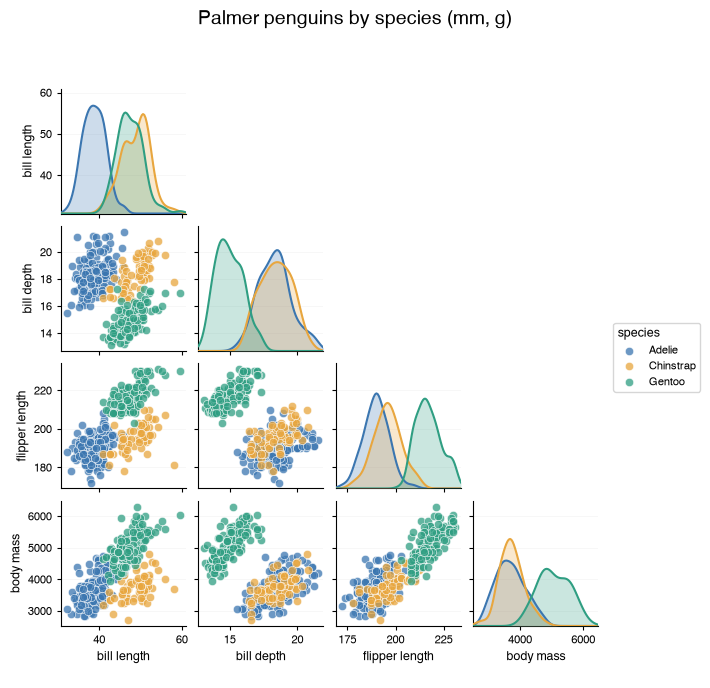

In [9]:
ScatterMatrix(
    penguins,
    title="Palmer penguins by species (mm, g)",
    dimensions=MEASUREMENTS,
    # color the points by species, and one density curve per species
    hue="species",
    diagonal=SCATTER_MATRIX_DIAGONAL.KDE,
    lower_only=True,
    show_legend=True,
    figsize=(7.0, 7.0),
).show()

The bill depth row is the one to read. Every cell in it slopes downward as a whole, and inside every cluster the same cell slopes *upward* — the three species sit on a diagonal staircase that the pooled cloud follows instead. This is Simpson's paradox, and it is the reason a correlation matrix should never be the last figure of an association section.

### Is it the mixture, or is it the outliers?

One pair deserves the close-up, and it comes with a second question: a Pearson correlation measures how close the points lie to a straight line and is pulled hard by a few extreme ones, while a Spearman correlation measures only whether the ranks move together and barely notices them. When the two disagree the culprit is usually an outlier or a curve; when they agree, as here, neither is the explanation and the mixture is.

Both coefficients come from the [statistics utilities](../../how-to-guides/utility/stats/) — `correlation` and `spearman` — and go into a `texts` note. The [scatter chart](../../how-to-guides/charts/scatterchart/) fits the pooled line itself with `show_regression`, and `hue` colors the points by species so the pooled line can be read against the groups it was fitted through.

In [10]:
PAIR = ("flipper length", "bill depth")
pearson = correlation(columns[PAIR[0]], columns[PAIR[1]])
rank = spearman(columns[PAIR[0]], columns[PAIR[1]])
within = {
    species: correlation(values(PAIR[0], species), values(PAIR[1], species))
    for species in SPECIES
}
within

{'Adelie': 0.3076201793966855,
 'Chinstrap': 0.5801428793349274,
 'Gentoo': 0.7065634484678057}

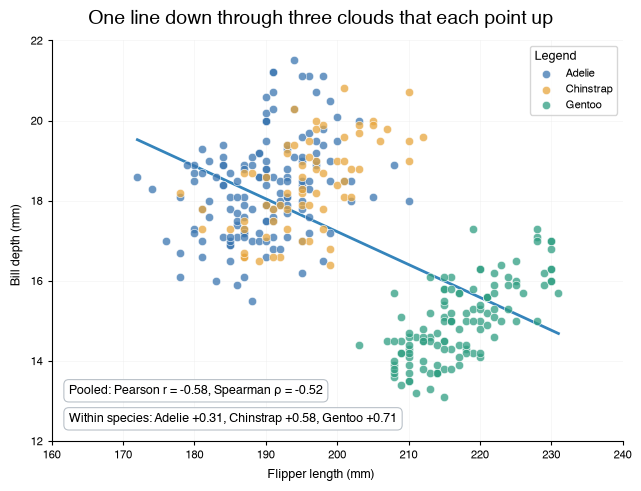

In [11]:
ScatterChart(
    [
        {"x": penguin[PAIR[0]], "y": penguin[PAIR[1]], "hue": penguin["species"]}
        for penguin in penguins
    ],
    title="One line down through three clouds that each point up",
    xlabel="Flipper length (mm)",
    ylabel="Bill depth (mm)",
    # the pooled fit, through all three species at once
    show_regression=True,
    texts=[
        {
            "text": f"Pooled: Pearson r = {pearson:.2f}, Spearman ρ = {rank:.2f}",
            "x": 0.03,
            "y": 0.11,
            "coords": "axes",
            "style": {**NOTE_STYLE, "plot_text_valign": "bottom"},
        },
        {
            "text": "Within species: "
            + ", ".join(f"{name} {value:+.2f}" for name, value in within.items()),
            "x": 0.03,
            "y": 0.04,
            "coords": "axes",
            "style": {**NOTE_STYLE, "plot_text_valign": "bottom"},
        },
    ],
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

Pearson and Spearman land about 0.06 apart, so the negative pooled figure is not the work of a handful of stray birds. Every species on its own gives a positive coefficient, and the largest of them is stronger than the pooled one is negative. The honest sentence for the report is that flipper length and bill depth rise together within a species, and that species differ enough in both to reverse the sign when they are pooled.

## Checking the model

### Does the straight line hold, and where does it fail?

Flipper length and body mass were the strongest pair in the matrix, so a straight line through them is the obvious model. Two figures check it, and they belong together: the fit itself, which says whether the line is plausible at all, and its residuals against the values it predicted, which say where it is wrong.

`linear_fit` returns the slope, the intercept and the r², so the residuals can be computed in the open rather than read off the chart. The [scatter chart](../../how-to-guides/charts/scatterchart/) draws the same fit with `show_regression` and shades its confidence band with `show_ci`. In the residual plot the reference is the zero line — an `hlines` mark — and the shape to look for is no shape: a horizontal band of even width. A [Grid](../../how-to-guides/utility/grid/) stacks the two, one above the other. The cells keep their own x-axes rather than sharing one, because the residuals are plotted against *fitted* values, not against flipper length.

In [12]:
flipper = np.array(values("flipper length"), dtype=float)
body_mass = np.array(values("body mass"), dtype=float)

slope, intercept, r2 = linear_fit(flipper, body_mass)
fitted = slope * flipper + intercept
residuals = body_mass - fitted
round(slope, 1), round(intercept, 1), round(r2, 3)

(49.7, -5780.8, 0.759)

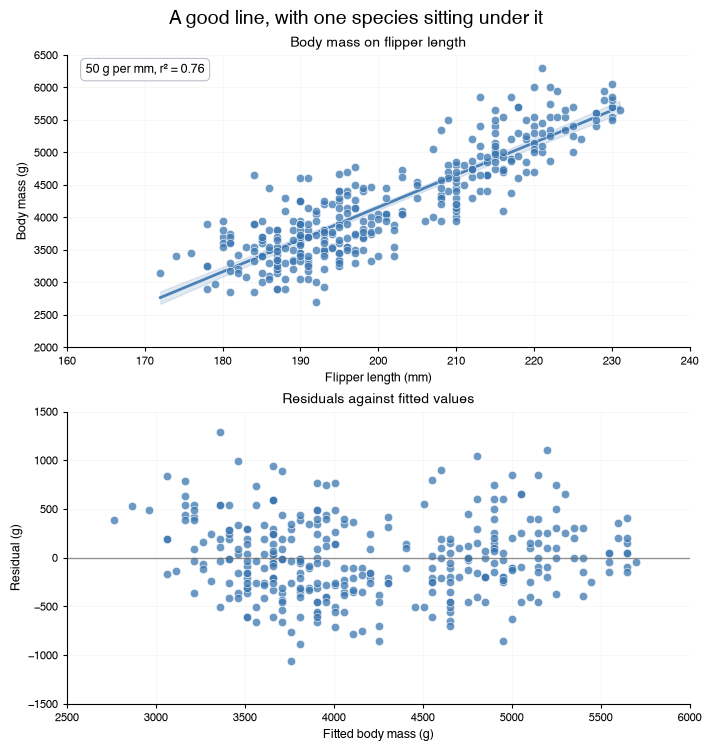

In [13]:
fit_figure = ScatterChart(
    [{"x": float(x), "y": float(y)} for x, y in zip(flipper, body_mass)],
    title="Body mass on flipper length",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    show_regression=True,
    show_ci=True,
    texts={
        "text": f"{slope:.0f} g per mm, r² = {r2:.2f}",
        "x": 0.03,
        "y": 0.95,
        "coords": "axes",
        "style": NOTE_STYLE,
    },
    show_grid=SHOW_GRID.BOTH,
)

residual_figure = ScatterChart(
    [{"x": float(x), "y": float(y)} for x, y in zip(fitted, residuals)],
    title="Residuals against fitted values",
    xlabel="Fitted body mass (g)",
    ylabel="Residual (g)",
    # the line a perfect prediction would sit on
    hlines={"y": 0, "style": REFERENCE_HLINE},
    show_grid=SHOW_GRID.BOTH,
)

Grid(
    [[fit_figure], [residual_figure]],
    title="A good line, with one species sitting under it",
    figsize=(7.0, 7.4),
).show()

The line explains about three quarters of the variation in body mass, and the residual band is flat and of even width — no curve the line missed, and no fan opening towards the heavy end. The one structure left is a dip in the middle of the range, where Chinstrap birds sit on average 216 g below the line: the species mixture the correlation figures found, showing up again as the thing a single line cannot absorb.

### Are the residuals normal enough to quote an interval?

Every interval and p-value a least-squares fit reports assumes its residuals are roughly normal. A Q-Q plot tests that by eye: sort the residuals, divide them by their standard deviation, and plot each against the value a standard normal distribution would have put in that position. If the assumption holds the points fall on the parity line, which is a `dlines` diagonal — the one reference mark a [scatter chart](../../how-to-guides/charts/scatterchart/) draws without a data series behind it.

The Shapiro-Wilk test answers the same question with one number, and the two belong together: the test says whether to reject, the figure says *where* the deviation is, and on 342 points a test will flag departures too small to matter.

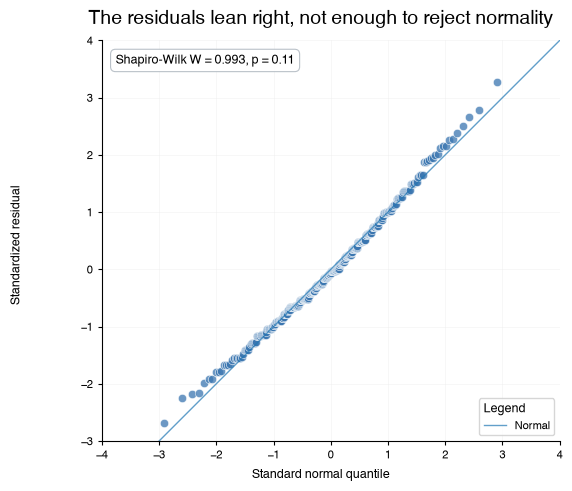

In [14]:
# ddof=2: the slope and the intercept were both estimated from these points
standardized = np.sort(residuals / residuals.std(ddof=2))
# Blom plotting positions: where a standard normal would put each rank
ranks = (np.arange(1, standardized.size + 1) - 0.375) / (standardized.size + 0.25)
theoretical = scipy_stats.norm.ppf(ranks)
shapiro = scipy_stats.shapiro(residuals)

qq_figure = ScatterChart(
    [{"x": float(x), "y": float(y)} for x, y in zip(theoretical, standardized)],
    title="The residuals lean right, not enough to reject normality",
    xlabel="Standard normal quantile",
    ylabel="Standardized residual",
    # the parity line the points would follow if they were normal
    dlines={"slope": 1, "intercept": 0, "label": "Normal"},
    texts={
        "text": f"Shapiro-Wilk W = {shapiro.statistic:.3f}, {as_p(shapiro.pvalue)}",
        "x": 0.03,
        "y": 0.95,
        "coords": "axes",
        "style": NOTE_STYLE,
    },
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
qq_figure.show()

The middle of the distribution lies on the line and both ends sit above it: the heaviest birds are further from the fit than a normal distribution allows, and the lightest are closer to it. That is a mild right skew rather than a heavy tail on both sides. Shapiro-Wilk does not reject at the 5% level, so the intervals the fit reports are usable, and the skew is worth a sentence rather than a different model.

### What do the distributions say with no model at all?

The first figure of this page drew densities, which means it drew a bandwidth choice. The last one draws none: an empirical cumulative distribution puts each observation at its own rank, so the curve is the data and nothing else. Any quantile can be read straight off it — the median is where the curve crosses 0.5 — and two curves that never touch are two distributions that do not overlap at all.

A [line chart](../../how-to-guides/charts/linechart/) draws it once the points are sorted, with `plot_line_drawstyle` set to a stepped style so the curve rises at the observations instead of sloping between them, which is what a smooth line would falsely imply.

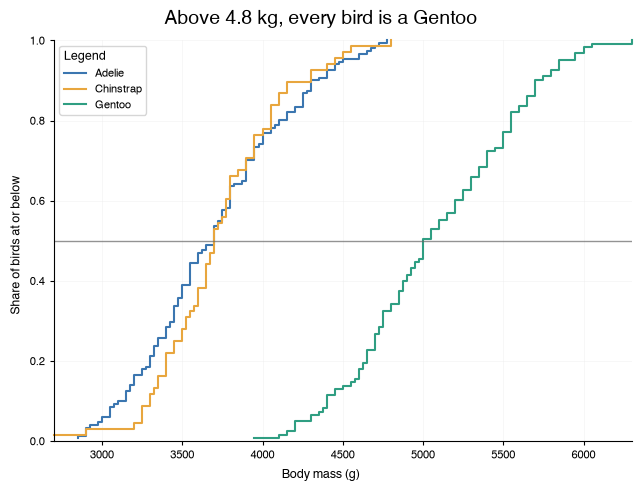

In [15]:
LineChart(
    [
        [
            {"x": float(value), "y": (rank + 1) / mass[species].size}
            for rank, value in enumerate(np.sort(mass[species]))
        ]
        for species in SPECIES
    ],
    title="Above 4.8 kg, every bird is a Gentoo",
    xlabel="Body mass (g)",
    ylabel="Share of birds at or below",
    subtitle=SPECIES,
    # the curve steps up at each bird instead of sloping between them
    style={"plot_line_drawstyle": LINE_DRAW_STYLE.STEPS_POST},
    # the level the median is read off
    hlines={"y": 0.5, "style": REFERENCE_HLINE},
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The Adelie and Chinstrap curves run through each other for their whole length, which is the non-significant pair of the first figure seen without any test. The Gentoo curve only starts where the other two are already seven tenths of the way up, and the horizontal 0.5 line crosses it about 1.3 kg further right — the same effect the second figure measured, read straight off the data.

## The report figure

A paper has room for one figure, not nine. The four that carry the argument — the groups differ, here is what moves with what, here is the model, and here is why its intervals can be trusted — go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures already drawn above and redraws them into its cells. Nested lists are the layout: one inner list per row.

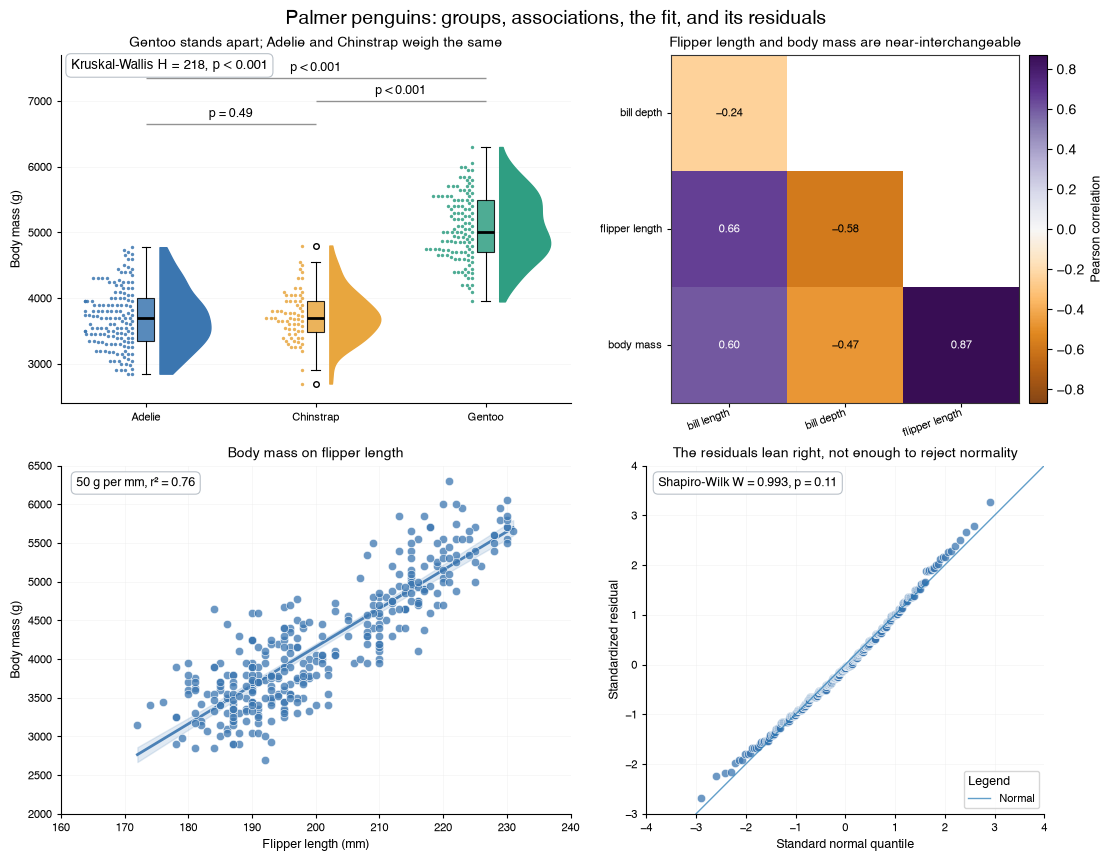

In [16]:
Grid(
    [
        [mass_figure, correlation_figure],
        [fit_figure, qq_figure],
    ],
    title="Palmer penguins: groups, associations, the fit, and its residuals",
    figsize=(11.0, 8.5),
).show()

Every figure on this page is one call to a chart function over a list of dicts, and every number in them comes from a `scipy.stats` call or a [statistics utility](../../how-to-guides/utility/stats/) written out in the cell above it. To adapt any of them, open the guide it links to and read the parameter that does the job. The charts index lists them all: [Charts](../../how-to-guides/charts/).